In [1]:
import pandas as pd

train = pd.read_csv("Train.csv")
train.head()

,ID,label,VH_01,VV_01,blue_01,green_01,nir_01,nira_01,re1_01,re2_01,...,blue_12,green_12,nir_12,nira_12,re1_12,re2_12,re3_12,red_12,swir1_12,swir2_12
0,ID_TR_NEW_XVGKFMLNRJ,0,-29.099645,-22.471573,1665,1719,1367,1270,1689,1416,...,1639,1826,1395,1384,1736,1449,1436,1626,1307,1216
1,ID_TR_NEW_GP8KNSWVP6,0,-19.470574,-10.752340,1579,1740,2245,2231,2060,2147,...,1490,1622,2090,2109,1924,1941,2020,1779,2298,2131
2,ID_TR_NEW_87X3957MVS,1,-20.964854,-8.792675,1850,2345,3664,3470,2935,3384,...,1438,1673,1335,1289,1588,1377,1307,1503,1237,1168
3,ID_TR_NEW_T4JMRPKHS3,0,-18.728208,-4.689202,1279,1297,1713,1698,1527,1531,...,1405,1550,2454,2397,1894,2040,2179,1748,2574,1977
4,ID_TR_NEW_2CTUQQ8KLU,0,-29.630941,-23.370157,1625,1741,1339,1258,1658,1362,...,1582,1856,1365,1306,1627,1370,1367,1641,1219,1147


In [2]:
train.shape

(1821, 146)

In [3]:
train.dtypes

ID              str
label         int64
VH_01       float64
VV_01       float64
blue_01       int64
             ...   
re2_12        int64
re3_12        int64
red_12        int64
swir1_12      int64
swir2_12      int64
Length: 146, dtype: object

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1821 entries, 0 to 1820
Columns: 146 entries, ID to swir2_12
dtypes: float64(24), int64(121), str(1)
memory usage: 2.0 MB


In [5]:
(train==-9999).sum()

ID          0
label       0
VH_01       0
VV_01       0
blue_01     0
           ..
re2_12      0
re3_12      0
red_12      0
swir1_12    0
swir2_12    0
Length: 146, dtype: int64

In [6]:
(train==-9999).sum().sum()

np.int64(0)

In [7]:
test = pd.read_csv("test.csv")

In [8]:
test.head()

,ID,VH_01,VV_01,blue_01,green_01,nir_01,nira_01,re1_01,re2_01,re3_01,...,blue_12,green_12,nir_12,nira_12,re1_12,re2_12,re3_12,red_12,swir1_12,swir2_12
0,ID_TS_NEW_SBZAYD5I,-9999.000000,-9999.000000,-9999,-9999,-9999,-9999,-9999,-9999,-9999,...,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999
1,ID_TS_NEW_7SPRN3PB,-34.017096,-22.539108,1540,1693,1300,1321,1629,1412,1378,...,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999
2,ID_TS_NEW_LZOWPHLC,-9999.000000,-9999.000000,-9999,-9999,-9999,-9999,-9999,-9999,-9999,...,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999
3,ID_TS_NEW_DN6TUF64,-9999.000000,-9999.000000,-9999,-9999,-9999,-9999,-9999,-9999,-9999,...,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999
4,ID_TS_NEW_95N82M49,-9999.000000,-9999.000000,-9999,-9999,-9999,-9999,-9999,-9999,-9999,...,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999,-9999


In [9]:
(test == -9999).sum().sum()

np.int64(89756)

In [10]:
test.shape

(1030, 145)

each test row reveals only 4–6 consecutive months, meaning 6–8 months are masked per row

missing months per row (avg ~7)  ×  12 bands per month  ≈  84 missing cells per row
84 × 1030 ≈ 86,520 so its close to 89,756

In [11]:
train.head()

,ID,label,VH_01,VV_01,blue_01,green_01,nir_01,nira_01,re1_01,re2_01,...,blue_12,green_12,nir_12,nira_12,re1_12,re2_12,re3_12,red_12,swir1_12,swir2_12
0,ID_TR_NEW_XVGKFMLNRJ,0,-29.099645,-22.471573,1665,1719,1367,1270,1689,1416,...,1639,1826,1395,1384,1736,1449,1436,1626,1307,1216
1,ID_TR_NEW_GP8KNSWVP6,0,-19.470574,-10.752340,1579,1740,2245,2231,2060,2147,...,1490,1622,2090,2109,1924,1941,2020,1779,2298,2131
2,ID_TR_NEW_87X3957MVS,1,-20.964854,-8.792675,1850,2345,3664,3470,2935,3384,...,1438,1673,1335,1289,1588,1377,1307,1503,1237,1168
3,ID_TR_NEW_T4JMRPKHS3,0,-18.728208,-4.689202,1279,1297,1713,1698,1527,1531,...,1405,1550,2454,2397,1894,2040,2179,1748,2574,1977
4,ID_TR_NEW_2CTUQQ8KLU,0,-29.630941,-23.370157,1625,1741,1339,1258,1658,1362,...,1582,1856,1365,1306,1627,1370,1367,1641,1219,1147


In [12]:
train["label"].value_counts()

label
0    1086
1     735
Name: count, dtype: int64

In [13]:
# proportions
train["label"].value_counts(normalize=True)

label
0    0.596376
1    0.403624
Name: proportion, dtype: float64

In [14]:
import matplotlib.pyplot as plt

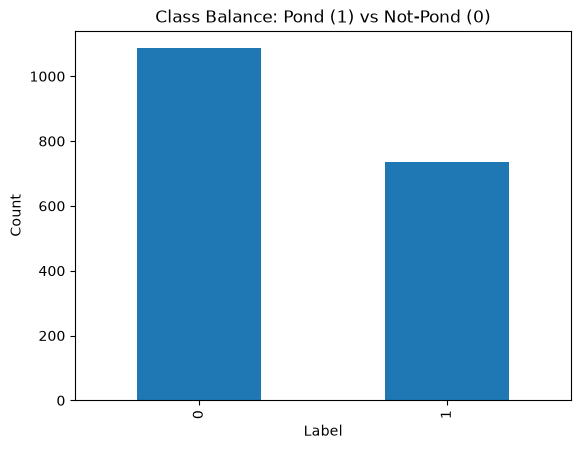

In [15]:
train["label"].value_counts().plot(kind="bar")
plt.title("Class Balance: Pond (1) vs Not-Pond (0)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [16]:
vh_columns = [f"VH_{m:02d}" for m in range(1, 13)]

In [17]:
vh_columns

['VH_01',
 'VH_02',
 'VH_03',
 'VH_04',
 'VH_05',
 'VH_06',
 'VH_07',
 'VH_08',
 'VH_09',
 'VH_10',
 'VH_11',
 'VH_12']

In [18]:
pond_avg = train[train["label"] == 1][vh_columns]
pond_avg

,VH_01,VH_02,VH_03,VH_04,VH_05,VH_06,VH_07,VH_08,VH_09,VH_10,VH_11,VH_12
2,-20.964854,-22.723501,-32.265795,-26.606786,-28.613416,-27.579135,-27.423641,-29.585175,-32.687598,-31.181865,-30.228160,-28.710411
8,-25.102608,-21.297063,-19.519926,-20.563862,-22.551753,-21.446592,-23.735414,-26.438197,-23.791508,-24.623142,-21.266314,-21.495868
12,-29.637932,-30.433108,-31.079827,-27.127317,-26.306547,-26.531892,-25.882746,-26.664203,-29.759437,-30.191174,-28.815664,-30.779315
13,-34.138587,-33.166906,-29.857632,-32.060895,-29.653082,-29.456783,-33.577606,-30.929547,-28.736568,-27.609299,-29.926465,-28.859869
14,-36.846636,-29.603131,-19.897848,-31.377379,-30.216835,-32.068494,-31.214570,-32.793247,-34.713137,-21.667828,-17.528380,-18.182636
...,...,...,...,...,...,...,...,...,...,...,...,...
1816,-21.699025,-24.146995,-29.741815,-29.345130,-29.397676,-31.217664,-37.863493,-30.420290,-30.010107,-27.958454,-30.446752,-26.162617
1817,-20.958733,-23.911183,-28.762571,-22.301853,-26.575115,-30.806398,-30.754435,-31.432618,-28.922025,-29.415369,-20.010198,-20.332116
1818,-22.437366,-20.891797,-23.583539,-23.238455,-17.290266,-20.967514,-20.234864,-19.516461,-18.952954,-19.317805,-23.287895,-24.424091
1819,-24.385467,-23.921263,-26.489862,-30.758143,-31.446426,-30.671134,-36.062786,-30.289375,-28.723814,-24.701310,-22.752875,-21.563787


In [19]:
notpond_avg = train[train["label"] == 0][vh_columns]
notpond_avg

,VH_01,VH_02,VH_03,VH_04,VH_05,VH_06,VH_07,VH_08,VH_09,VH_10,VH_11,VH_12
0,-29.099645,-30.293645,-25.825494,-28.604696,-27.125389,-36.058930,-30.026146,-28.345876,-25.347438,-30.503403,-28.004794,-27.869169
1,-19.470574,-18.745639,-21.769029,-20.684984,-18.440298,-15.908768,-15.996166,-15.421053,-13.722553,-15.806885,-18.138170,-18.873062
3,-18.728208,-17.384014,-19.614806,-17.334069,-15.908645,-15.318855,-16.550673,-17.744163,-17.848901,-17.016158,-18.489561,-19.448225
4,-29.630941,-40.648601,-29.428377,-37.570250,-27.595630,-28.590082,-27.608347,-30.122815,-27.725869,-29.728627,-34.730984,-32.431551
5,-29.169946,-27.028216,-29.898119,-29.676688,-34.265683,-28.581145,-32.405271,-28.756769,-28.607655,-30.403169,-35.527596,-31.219257
...,...,...,...,...,...,...,...,...,...,...,...,...
1810,-22.459914,-20.652305,-21.380272,-18.959164,-19.615705,-18.722460,-17.633780,-18.566991,-18.756891,-19.399627,-19.639779,-20.241418
1812,-31.252336,-28.354529,-39.024265,-32.642828,-28.550227,-29.443178,-32.638919,-35.513297,-36.603695,-28.860343,-29.404337,-29.992904
1813,-18.646352,-20.266675,-25.980801,-17.106643,-22.338856,-19.560535,-16.473915,-14.420160,-13.012825,-15.401600,-15.165949,-19.555380
1814,-18.734098,-16.193244,-19.151720,-18.049993,-15.506037,-15.655544,-17.298418,-16.635061,-16.325335,-15.875585,-17.613417,-19.445710


In [20]:
pond_avg = train[train["label"] == 1][vh_columns].mean()
notpond_avg = train[train["label"] == 0][vh_columns].mean()

In [21]:
(pond_avg, notpond_avg)

(VH_01   -26.687616
 VH_02   -27.484230
 VH_03   -30.252898
 VH_04   -30.627621
 VH_05   -30.249984
 VH_06   -30.957833
 VH_07   -30.996965
 VH_08   -30.562040
 VH_09   -29.386893
 VH_10   -28.572893
 VH_11   -27.436470
 VH_12   -26.649766
 dtype: float64,
 VH_01   -24.494737
 VH_02   -24.499972
 VH_03   -24.536978
 VH_04   -22.795654
 VH_05   -22.208776
 VH_06   -22.665081
 VH_07   -22.681504
 VH_08   -22.233802
 VH_09   -21.746112
 VH_10   -22.182730
 VH_11   -22.993929
 VH_12   -23.591467
 dtype: float64)

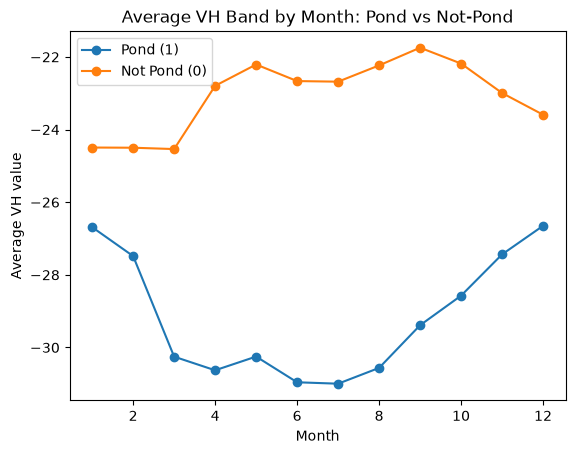

In [22]:
plt.plot(range(1, 13), pond_avg, label="Pond (1)", marker="o")
plt.plot(range(1, 13), notpond_avg, label="Not Pond (0)", marker="o")
plt.title("Average VH Band by Month: Pond vs Not-Pond")
plt.xlabel("Month")
plt.ylabel("Average VH value")
plt.legend()
plt.show()

VH is different for ponds and different for not-ponds.

In [23]:
train.head()

,ID,label,VH_01,VV_01,blue_01,green_01,nir_01,nira_01,re1_01,re2_01,...,blue_12,green_12,nir_12,nira_12,re1_12,re2_12,re3_12,red_12,swir1_12,swir2_12
0,ID_TR_NEW_XVGKFMLNRJ,0,-29.099645,-22.471573,1665,1719,1367,1270,1689,1416,...,1639,1826,1395,1384,1736,1449,1436,1626,1307,1216
1,ID_TR_NEW_GP8KNSWVP6,0,-19.470574,-10.752340,1579,1740,2245,2231,2060,2147,...,1490,1622,2090,2109,1924,1941,2020,1779,2298,2131
2,ID_TR_NEW_87X3957MVS,1,-20.964854,-8.792675,1850,2345,3664,3470,2935,3384,...,1438,1673,1335,1289,1588,1377,1307,1503,1237,1168
3,ID_TR_NEW_T4JMRPKHS3,0,-18.728208,-4.689202,1279,1297,1713,1698,1527,1531,...,1405,1550,2454,2397,1894,2040,2179,1748,2574,1977
4,ID_TR_NEW_2CTUQQ8KLU,0,-29.630941,-23.370157,1625,1741,1339,1258,1658,1362,...,1582,1856,1365,1306,1627,1370,1367,1641,1219,1147


In [24]:
nir_columns = [f"nir_{i:02d}" for i in range(1, 13)]
nir_columns

['nir_01',
 'nir_02',
 'nir_03',
 'nir_04',
 'nir_05',
 'nir_06',
 'nir_07',
 'nir_08',
 'nir_09',
 'nir_10',
 'nir_11',
 'nir_12']

In [25]:
pond_avg = train[train["label"]== 1][nir_columns].mean()
pond_avg

nir_01    2262.070748
nir_02    2093.597279
nir_03    1755.556463
nir_04    1506.887075
nir_05    1825.623129
nir_06    1935.289796
nir_07    1863.870748
nir_08    1706.269388
nir_09    1682.051701
nir_10    1878.317007
nir_11    2115.420408
nir_12    2099.789116
dtype: float64

In [26]:
notpond_avg = train[train["label"] == 0][nir_columns].mean()
notpond_avg

nir_01    2355.511050
nir_02    2509.407919
nir_03    2664.376611
nir_04    2982.088398
nir_05    3039.766114
nir_06    3283.302026
nir_07    3511.484346
nir_08    3662.189687
nir_09    3330.398711
nir_10    2934.402394
nir_11    2564.550645
nir_12    2441.374770
dtype: float64

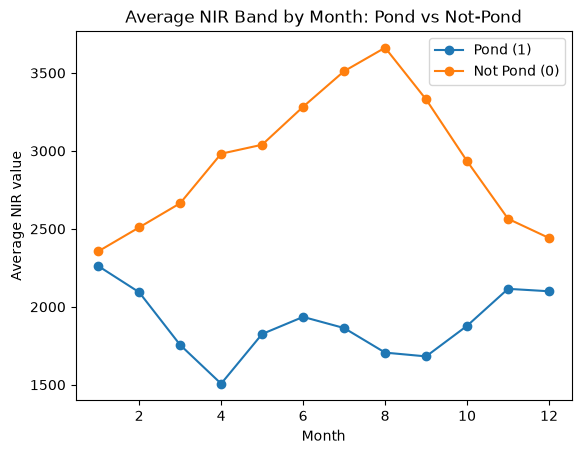

In [27]:
plt.plot(range(1, 13), pond_avg, label="Pond (1)", marker="o")
plt.plot(range(1, 13), notpond_avg, label="Not Pond (0)", marker="o")
plt.title("Average NIR Band by Month: Pond vs Not-Pond")
plt.xlabel("Month")
plt.ylabel("Average NIR value")
plt.legend()
plt.show()

NIR is different for ponds and different for not-ponds.

In [28]:
band_names = ["VH", "VV", "blue", "green", "red", "re1", "re2", "re3",
              "nir", "nira", "swir1", "swir2"]

for band in band_names:
    cols = [f"{band}_{m:02d}" for m in range(1, 13)]
    pond_mean = train[train["label"] == 1][cols].mean().mean()
    notpond_mean = train[train["label"] == 0][cols].mean().mean()
    diff = pond_mean - notpond_mean
    print(f"{band:8s} pond avg={pond_mean:8.2f}  notpond avg={notpond_mean:8.2f}  diff={diff:8.2f}")

VH       pond avg=  -29.16  notpond avg=  -23.05  diff=   -6.10
VV       pond avg=  -18.51  notpond avg=  -14.40  diff=   -4.11
blue     pond avg= 1761.95  notpond avg= 1632.96  diff=  128.99
green    pond avg= 2098.28  notpond avg= 1863.34  diff=  234.95
red      pond avg= 1914.46  notpond avg= 1895.90  diff=   18.57
re1      pond avg= 2173.19  notpond avg= 2229.26  diff=  -56.07
re2      pond avg= 1899.82  notpond avg= 2711.61  diff= -811.79
re3      pond avg= 1935.02  notpond avg= 2891.85  diff= -956.83
nir      pond avg= 1893.73  notpond avg= 2939.90  diff=-1046.18
nira     pond avg= 1828.35  notpond avg= 2984.97  diff=-1156.63
swir1    pond avg= 1735.07  notpond avg= 2696.96  diff= -961.88
swir2    pond avg= 1568.99  notpond avg= 2240.21  diff= -671.22


In [29]:
band_names = ["VH", "VV", "blue", "green", "red", "re1", "re2", "re3",
              "nir", "nira", "swir1", "swir2"]
band_names

['VH',
 'VV',
 'blue',
 'green',
 'red',
 're1',
 're2',
 're3',
 'nir',
 'nira',
 'swir1',
 'swir2']

In [30]:
for band in band_names:
    print(band)

VH
VV
blue
green
red
re1
re2
re3
nir
nira
swir1
swir2


In [31]:
for band in band_names:
    cols = [f"{band}_{m:02d}" for m in range(1, 13)]
    print(band, "->", cols)

VH -> ['VH_01', 'VH_02', 'VH_03', 'VH_04', 'VH_05', 'VH_06', 'VH_07', 'VH_08', 'VH_09', 'VH_10', 'VH_11', 'VH_12']
VV -> ['VV_01', 'VV_02', 'VV_03', 'VV_04', 'VV_05', 'VV_06', 'VV_07', 'VV_08', 'VV_09', 'VV_10', 'VV_11', 'VV_12']
blue -> ['blue_01', 'blue_02', 'blue_03', 'blue_04', 'blue_05', 'blue_06', 'blue_07', 'blue_08', 'blue_09', 'blue_10', 'blue_11', 'blue_12']
green -> ['green_01', 'green_02', 'green_03', 'green_04', 'green_05', 'green_06', 'green_07', 'green_08', 'green_09', 'green_10', 'green_11', 'green_12']
red -> ['red_01', 'red_02', 'red_03', 'red_04', 'red_05', 'red_06', 'red_07', 'red_08', 'red_09', 'red_10', 'red_11', 'red_12']
re1 -> ['re1_01', 're1_02', 're1_03', 're1_04', 're1_05', 're1_06', 're1_07', 're1_08', 're1_09', 're1_10', 're1_11', 're1_12']
re2 -> ['re2_01', 're2_02', 're2_03', 're2_04', 're2_05', 're2_06', 're2_07', 're2_08', 're2_09', 're2_10', 're2_11', 're2_12']
re3 -> ['re3_01', 're3_02', 're3_03', 're3_04', 're3_05', 're3_06', 're3_07', 're3_08', 're

In [32]:
for band in band_names:
    cols = [f"{band}_{m:02d}" for m in range(1, 13)]
    pond_mean = train[train["label"] == 1][cols].mean().mean()
    print(band, "-> pond average:", pond_mean)

VH -> pond average: -29.155434061070295
VV -> pond average: -18.50664385084025
blue -> pond average: 1761.9467120181407
green -> pond average: 2098.2846938775506
red -> pond average: 1914.464172335601
re1 -> pond average: 2173.1902494331066
re2 -> pond average: 1899.8185941043084
re3 -> pond average: 1935.021768707483
nir -> pond average: 1893.728571428571
nira -> pond average: 1828.3461451247167
swir1 -> pond average: 1735.0743764172337
swir2 -> pond average: 1568.9931972789118


In [33]:
for band in band_names:
    cols = [f"{band}_{m:02d}" for m in range(1, 13)]
    pond_mean = train[train["label"] == 1][cols].mean().mean()
    notpond_mean = train[train["label"] == 0][cols].mean().mean()
    print(band, "-> pond avg:", pond_mean, " | notpond avg:", notpond_mean)

VH -> pond avg: -29.155434061070295  | notpond avg: -23.05256182896539
VV -> pond avg: -18.50664385084025  | notpond avg: -14.400384967942529
blue -> pond avg: 1761.9467120181407  | notpond avg: 1632.9614027010437
green -> pond avg: 2098.2846938775506  | notpond avg: 1863.33824432167
red -> pond avg: 1914.464172335601  | notpond avg: 1895.8977900552484
re1 -> pond avg: 2173.1902494331066  | notpond avg: 2229.2627378759976
re2 -> pond avg: 1899.8185941043084  | notpond avg: 2711.6124155923876
re3 -> pond avg: 1935.021768707483  | notpond avg: 2891.8494475138123
nir -> pond avg: 1893.728571428571  | notpond avg: 2939.904389195826
nira -> pond avg: 1828.3461451247167  | notpond avg: 2984.9749079189683
swir1 -> pond avg: 1735.0743764172337  | notpond avg: 2696.9573357888275
swir2 -> pond avg: 1568.9931972789118  | notpond avg: 2240.209484346224


In [34]:
for band in band_names:
    cols = [f"{band}_{m:02d}" for m in range(1, 13)]
    pond_mean = train[train["label"] == 1][cols].mean().mean()
    notpond_mean = train[train["label"] == 0][cols].mean().mean()
    diff = pond_mean - notpond_mean
    print(band, "-> pond avg:", pond_mean, " | notpond avg:", notpond_mean, " | diff:", diff)

VH -> pond avg: -29.155434061070295  | notpond avg: -23.05256182896539  | diff: -6.102872232104904
VV -> pond avg: -18.50664385084025  | notpond avg: -14.400384967942529  | diff: -4.10625888289772
blue -> pond avg: 1761.9467120181407  | notpond avg: 1632.9614027010437  | diff: 128.98530931709706
green -> pond avg: 2098.2846938775506  | notpond avg: 1863.33824432167  | diff: 234.9464495558807
red -> pond avg: 1914.464172335601  | notpond avg: 1895.8977900552484  | diff: 18.566382280352627
re1 -> pond avg: 2173.1902494331066  | notpond avg: 2229.2627378759976  | diff: -56.07248844289097
re2 -> pond avg: 1899.8185941043084  | notpond avg: 2711.6124155923876  | diff: -811.7938214880792
re3 -> pond avg: 1935.021768707483  | notpond avg: 2891.8494475138123  | diff: -956.8276788063292
nir -> pond avg: 1893.728571428571  | notpond avg: 2939.904389195826  | diff: -1046.1758177672548
nira -> pond avg: 1828.3461451247167  | notpond avg: 2984.9749079189683  | diff: -1156.6287627942515
swir1 -> pon

In [35]:
train["VH_01"].std()

np.float64(5.586461286107808)

In [36]:
for band in band_names:
    cols = [f"{band}_{m:02d}" for m in range(1, 13)]
    pond_mean = train[train["label"] == 1][cols].mean().mean()
    notpond_mean = train[train["label"] == 0][cols].mean().mean()
    diff = pond_mean - notpond_mean
    spread = train[cols].std().mean()
    print(band, "-> diff:", diff, " | spread:", spread)

VH -> diff: -6.102872232104904  | spread: 6.316188467393544
VV -> diff: -4.10625888289772  | spread: 5.569621150329875
blue -> diff: 128.98530931709706  | spread: 335.9830239062357
green -> diff: 234.9464495558807  | spread: 390.1870347021509
red -> diff: 18.566382280352627  | spread: 482.8804979528781
re1 -> diff: -56.07248844289097  | spread: 506.05757126148865
re2 -> diff: -811.7938214880792  | spread: 947.0566772491176
re3 -> diff: -956.8276788063292  | spread: 1076.7778136112415
nir -> diff: -1046.1758177672548  | spread: 1142.1911464911152
nira -> diff: -1156.6287627942515  | spread: 1195.220607356772
swir1 -> diff: -961.8829593715939  | spread: 1036.6458267728185
swir2 -> diff: -671.2162870673124  | spread: 818.7612693996122


In [37]:
results = []

for band in band_names:
    cols = [f"{band}_{m:02d}" for m in range(1, 13)]
    pond_mean = train[train["label"] == 1][cols].mean().mean()
    notpond_mean = train[train["label"] == 0][cols].mean().mean()
    diff = pond_mean - notpond_mean
    spread = train[cols].std().mean()
    ratio = diff / spread
    results.append((band, ratio))

results.sort(key=lambda x: abs(x[1]), reverse=True)

for band, ratio in results:
    print(band, "-> ratio:", ratio)

nira -> ratio: -0.9677115301351219
VH -> ratio: -0.9662270629842894
swir1 -> ratio: -0.9278800285783536
nir -> ratio: -0.9159376002704751
re3 -> ratio: -0.8886027058798418
re2 -> ratio: -0.8571755429105556
swir2 -> ratio: -0.8197948683619429
VV -> ratio: -0.7372599988518996
green -> ratio: 0.602138022692699
blue -> ratio: 0.383904245570138
re1 -> ratio: -0.11080258774335648
red -> ratio: 0.03844922782978995


### Filling in -9999 with the Median

In [38]:
train_clean = train.replace(-9999, pd.NA)

In [39]:
train_clean

,ID,label,VH_01,VV_01,blue_01,green_01,nir_01,nira_01,re1_01,re2_01,...,blue_12,green_12,nir_12,nira_12,re1_12,re2_12,re3_12,red_12,swir1_12,swir2_12
0,ID_TR_NEW_XVGKFMLNRJ,0,-29.099645,-22.471573,1665,1719,1367,1270,1689,1416,...,1639,1826,1395,1384,1736,1449,1436,1626,1307,1216
1,ID_TR_NEW_GP8KNSWVP6,0,-19.470574,-10.752340,1579,1740,2245,2231,2060,2147,...,1490,1622,2090,2109,1924,1941,2020,1779,2298,2131
2,ID_TR_NEW_87X3957MVS,1,-20.964854,-8.792675,1850,2345,3664,3470,2935,3384,...,1438,1673,1335,1289,1588,1377,1307,1503,1237,1168
3,ID_TR_NEW_T4JMRPKHS3,0,-18.728208,-4.689202,1279,1297,1713,1698,1527,1531,...,1405,1550,2454,2397,1894,2040,2179,1748,2574,1977
4,ID_TR_NEW_2CTUQQ8KLU,0,-29.630941,-23.370157,1625,1741,1339,1258,1658,1362,...,1582,1856,1365,1306,1627,1370,1367,1641,1219,1147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1816,ID_TR_NEW_JFTRFXYWTU,1,-21.699025,-8.926699,1972,2345,2901,2998,2809,2922,...,1878,2187,2691,2698,2531,2596,2635,2300,2917,2497
1817,ID_TR_NEW_P2NF9JJLP4,1,-20.958733,-11.072085,2275,2655,3294,3289,3070,3209,...,1856,2161,2791,2831,2675,2781,2836,2142,2615,2020
1818,ID_TR_NEW_RUHQAP9B6B,1,-22.437366,-12.874400,1840,2062,3127,3061,2409,2869,...,1585,1694,2556,2668,2108,2316,2430,1856,3537,2919
1819,ID_TR_NEW_SNKAUJLCP6,1,-24.385467,-12.004854,1886,2215,3003,2930,2590,2800,...,1873,2230,2766,2779,2531,2736,2779,2090,2723,2181


In [40]:
train_clean.isna().sum().sum()

np.int64(0)

confirming train really has no placeholders to convert

### Converting -9999 to real missing values in test

In [41]:
test_clean = test.replace(-9999, pd.NA)
test_clean

,ID,VH_01,VV_01,blue_01,green_01,nir_01,nira_01,re1_01,re2_01,re3_01,...,blue_12,green_12,nir_12,nira_12,re1_12,re2_12,re3_12,red_12,swir1_12,swir2_12
0,ID_TS_NEW_SBZAYD5I,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,ID_TS_NEW_7SPRN3PB,-34.017096,-22.539108,1540,1693,1300,1321,1629,1412,1378,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,ID_TS_NEW_LZOWPHLC,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,ID_TS_NEW_DN6TUF64,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,ID_TS_NEW_95N82M49,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,ID_TS_NEW_SNWDIVQC,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1026,ID_TS_NEW_PU4TWGVJ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1027,ID_TS_NEW_DLHNL6WW,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1028,ID_TS_NEW_RFBCIMPB,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [42]:
test_clean.isna().sum().sum()

np.int64(89756)

In [43]:
medians = train_clean.median(numeric_only=True)

In [44]:
medians


label          0.000000
VH_01        -23.945252
VV_01        -13.290349
blue_01     1627.000000
green_01    1815.000000
               ...     
re2_12      2106.000000
re3_12      2166.000000
red_12      1777.000000
swir1_12    2509.000000
swir2_12    1994.000000
Length: 145, dtype: float64

In [45]:
train_filled = train_clean.fillna(medians)
test_filled = test_clean.fillna(medians)

train_filled.isna().sum().sum(), test_filled.isna().sum().sum()

(np.int64(0), np.int64(0))

In [46]:
test_filled

,ID,VH_01,VV_01,blue_01,green_01,nir_01,nira_01,re1_01,re2_01,re3_01,...,blue_12,green_12,nir_12,nira_12,re1_12,re2_12,re3_12,red_12,swir1_12,swir2_12
0,ID_TS_NEW_SBZAYD5I,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
1,ID_TS_NEW_7SPRN3PB,-34.017096,-22.539108,1540,1693,1300,1321,1629,1412,1378,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
2,ID_TS_NEW_LZOWPHLC,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
3,ID_TS_NEW_DN6TUF64,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
4,ID_TS_NEW_95N82M49,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,ID_TS_NEW_SNWDIVQC,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
1026,ID_TS_NEW_PU4TWGVJ,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
1027,ID_TS_NEW_DLHNL6WW,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
1028,ID_TS_NEW_RFBCIMPB,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0


### Creating the Train/Validation Split

In [47]:
from sklearn.model_selection import train_test_split
X = train_filled.drop(columns=["ID", "label"])
y = train_filled["label"]

In [48]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_val.shape

((1456, 144), (365, 144))

Creating the Train/Validation Split

In [49]:
from sklearn.model_selection import train_test_split

X = train_filled.drop(columns=["ID", "label"])
y = train_filled["label"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_val.shape

((1456, 144), (365, 144))

In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

C:\Users\Hp\miniconda3\envs\aqua-ponds\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [53]:
X_train_scaled


array([[ 0.15898643,  0.24792107, -0.28616987, ...,  1.05873741,
         0.9443401 ,  1.31601012],
       [-0.72162269, -0.07390348,  1.35789859, ...,  0.53674675,
         0.65741036,  0.89732887],
       [-0.66996041, -1.48537108, -1.56041448, ..., -1.5223943 ,
        -1.36387607, -1.27067877],
       ...,
       [-0.72259902, -1.29015653,  0.14223995, ...,  0.43747246,
        -1.26629673, -1.20977968],
       [ 1.26158467,  0.72149411, -0.55346831, ..., -0.23823324,
         0.52498125,  0.65677746],
       [-1.86079653, -2.01639988, -1.38831822, ..., -1.31103612,
        -1.37897764, -1.30874071]], shape=(1456, 144))

In [54]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [55]:
val_predictions = model.predict(X_val_scaled)
val_predictions[:10]

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1])

In [56]:
val_probs = model.predict_proba(X_val_scaled)
val_probs[:5]

array([[9.99399140e-01, 6.00860233e-04],
       [9.99983047e-01, 1.69526916e-05],
       [9.99712481e-01, 2.87519406e-04],
       [4.72449993e-03, 9.95275500e-01],
       [9.99980683e-01, 1.93167981e-05]])

In [57]:
pond_probs = val_probs[:, 1]
pond_probs[:5]

array([6.00860233e-04, 1.69526916e-05, 2.87519406e-04, 9.95275500e-01,
       1.93167981e-05])

In [58]:
from sklearn.metrics import f1_score, roc_auc_score

f1 = f1_score(y_val, val_predictions)
auc = roc_auc_score(y_val, pond_probs)

print("F1 score:", f1)
print("ROC-AUC score:", auc)

F1 score: 0.972972972972973
ROC-AUC score: 0.9965126416739319


In [60]:
X_test_final

,VH_01,VV_01,blue_01,green_01,nir_01,nira_01,re1_01,re2_01,re3_01,red_01,...,blue_12,green_12,nir_12,nira_12,re1_12,re2_12,re3_12,red_12,swir1_12,swir2_12
0,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,1821.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
1,-34.017096,-22.539108,1540,1693,1300,1321,1629,1412,1378,1580,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
2,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,1821.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
3,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,1821.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
4,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,1821.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,1821.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
1026,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,1821.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
1027,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,1821.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0
1028,-23.945252,-13.290349,1627.0,1815.0,2333.0,2326.0,2067.0,2147.0,2221.0,1821.0,...,1579.0,1798.0,2251.0,2275.0,2037.0,2106.0,2166.0,1777.0,2509.0,1994.0


In [59]:
X_test_final = test_filled.drop(columns=["ID"])
X_test_scaled = scaler.transform(X_test_final)

test_preds = model.predict(X_test_scaled)
test_probs = model.predict_proba(X_test_scaled)[:, 1]

In [61]:
submission = test_filled[["ID"]].copy()
submission["TargetF1"] = test_preds
submission["TargetRAUC"] = test_probs

submission.to_csv("submission_v1.csv", index=False)
submission.head()

,ID,TargetF1,TargetRAUC
0,ID_TS_NEW_SBZAYD5I,1,0.999081
1,ID_TS_NEW_7SPRN3PB,1,0.663030
2,ID_TS_NEW_LZOWPHLC,1,0.989802
3,ID_TS_NEW_DN6TUF64,1,0.996980
4,ID_TS_NEW_95N82M49,0,0.223753
